__Librerias Necesarias__

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

__Cargando Data__

In [86]:
data_mercado = pd.read_csv("cluster_mercado.csv")
data_mercado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Embutidos  90 non-null     float64
 1   Pescado    90 non-null     float64
 2   Pollo      90 non-null     float64
 3   Carne      90 non-null     float64
dtypes: float64(4)
memory usage: 2.9 KB


__Analisis Exploratorio__

In [87]:
data_mercado.describe()

,Embutidos,Pescado,Pollo,Carne
count,90.000000,90.000000,90.000000,90.000000
mean,46.834444,51.828889,37.042222,43.014444
std,11.888103,19.426770,15.769491,20.537872
min,21.300000,20.400000,5.200000,7.300000
25%,39.425000,37.225000,25.650000,25.075000
50%,46.350000,44.150000,35.650000,39.450000
75%,56.550000,71.200000,49.425000,62.400000
max,71.100000,95.600000,69.300000,80.500000


In [88]:
data_mercado.corr()

,Embutidos,Pescado,Pollo,Carne
Embutidos,1.000000,0.053112,0.317349,-0.501445
Pescado,0.053112,1.000000,0.708391,-0.660753
Pollo,0.317349,0.708391,1.000000,-0.759839
Carne,-0.501445,-0.660753,-0.759839,1.000000


<Axes: >

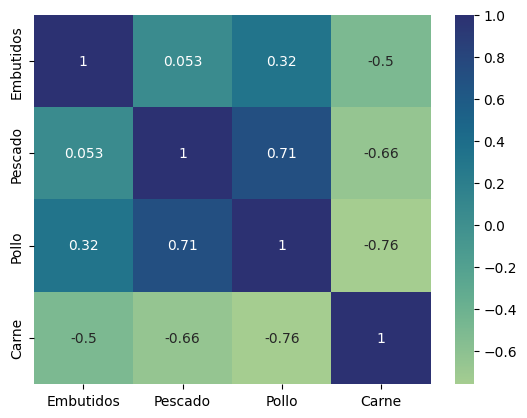

In [89]:
sns.heatmap(data_mercado.corr(), cmap="crest", annot=True)

__Observarcion__

Podemos apreciar que hay cierta relacion con la compra de pollo y de pescado, mientras que la relacion negativa del pollo y la carne, pudiera mostrarnos una sustitución del producto, es decir, quien no compra pollo, lo sustituye con carne (res).

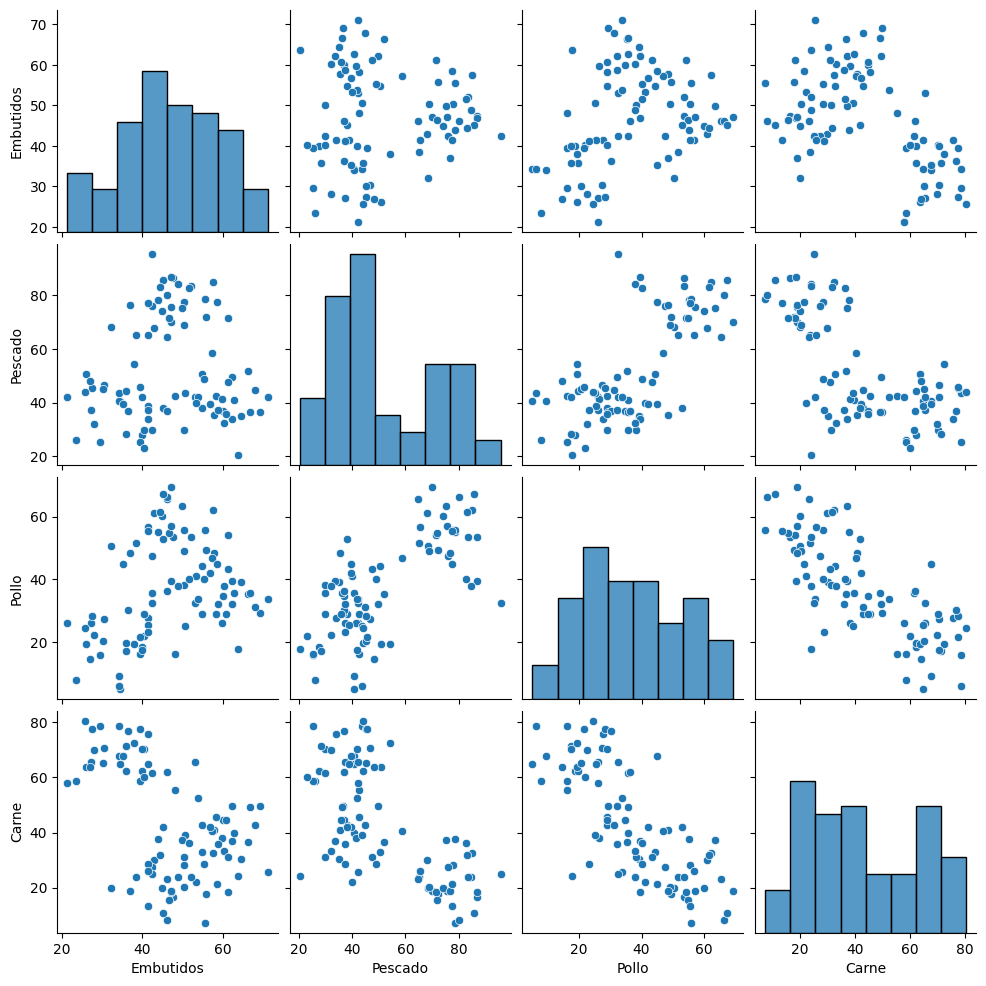

In [90]:
sns.pairplot(data_mercado)

<Axes: >

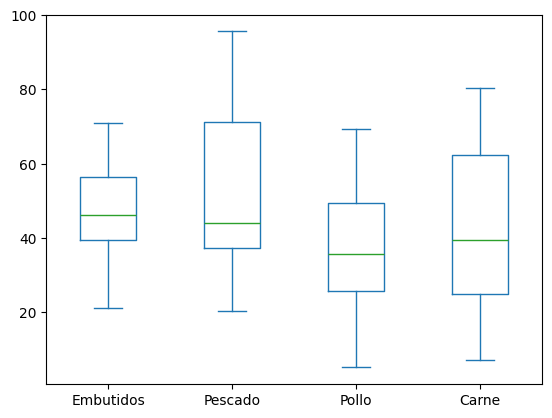

In [91]:
data_mercado.plot.box()

In [92]:
data_mercado.mean()

Embutidos    46.834444
Pescado      51.828889
Pollo        37.042222
Carne        43.014444
dtype: float64

__Identificando el Numero Optimo de Cluster__

Estandarizacion

In [93]:
from sklearn.preprocessing import StandardScaler

In [94]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_mercado)

<Axes: >

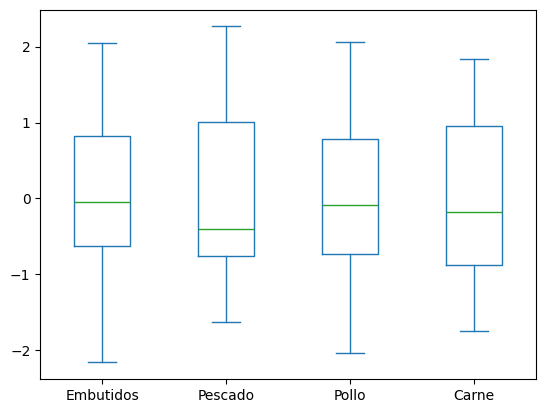

In [95]:
pd.DataFrame(scaled_data, columns=data_mercado.columns).plot.box()

<Axes: ylabel='Density'>

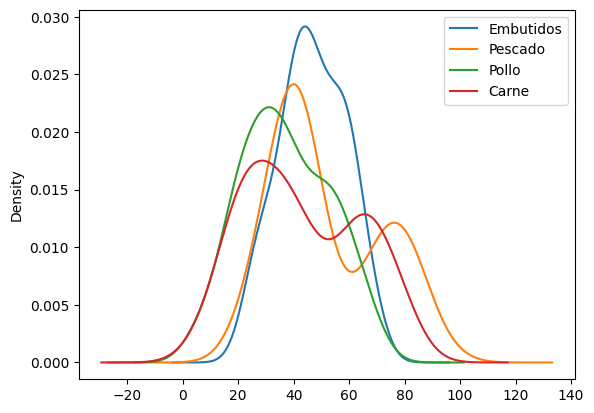

In [96]:
data_mercado.plot.kde()

<Axes: ylabel='Density'>

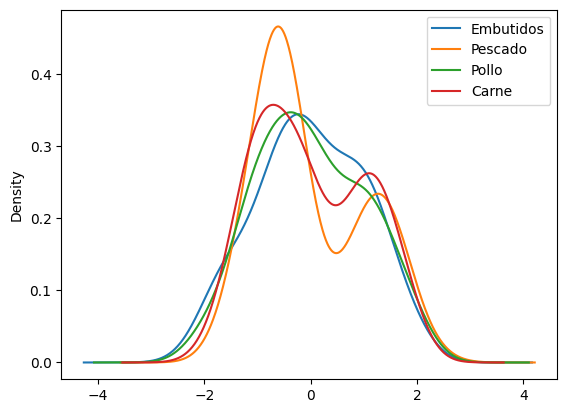

In [97]:
pd.DataFrame(scaled_data, columns=data_mercado.columns).plot.kde()

In [98]:
pd.DataFrame(scaled_data, columns=data_mercado.columns).describe()

,Embutidos,Pescado,Pollo,Carne
count,9.000000e+01,9.000000e+01,9.000000e+01,9.000000e+01
mean,-5.094690e-16,-7.894919e-17,3.207311e-17,1.085551e-16
std,1.005602e+00,1.005602e+00,1.005602e+00,1.005602e+00
min,-2.159932e+00,-1.626877e+00,-2.030542e+00,-1.748698e+00
25%,-6.267572e-01,-7.559519e-01,-7.264689e-01,-8.783747e-01
50%,-4.097865e-02,-3.974880e-01,-8.878041e-02,-1.745270e-01
75%,8.218287e-01,1.002721e+00,7.896355e-01,9.491811e-01
max,2.052598e+00,2.265756e+00,2.057041e+00,1.835417e+00


__Algoritmo K Means Y Entrenamiento__

In [99]:
from sklearn.cluster import KMeans

__Cuántos Cluster Deberiamos Usar?__

Haciendo un elbow analysis, vemos que a partir de 3 segmentaciones ya no obtenemos mejoria, esta vendría siendo muy granular y ya no tan eficiente. Por lo que k = 3

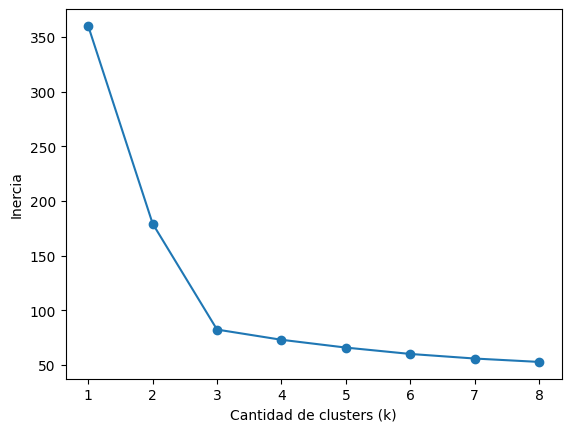

In [100]:
inertia = []
max_k = 8
for k in range(1,max_k+1):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,max_k+1), inertia, marker='o')
plt.xlabel('Cantidad de clusters (k)')
plt.ylabel('Inercia')
plt.show()

In [101]:
k = 3
kmeans = KMeans(n_clusters=k) 

In [102]:
kmeans.fit(scaled_data)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


Resultados

In [103]:
kmeans.labels_

array([0, 2, 0, 0, 0, 0, 1, 2, 0, 2, 1, 0, 0, 2, 2, 1, 1, 1, 0, 0, 2, 2,
       1, 0, 2, 1, 1, 2, 1, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 2, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 2, 0, 0, 1, 2, 2, 1, 0, 0, 2, 1, 2,
       2, 1, 2, 1, 2, 2, 2, 2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       2, 1], dtype=int32)

__Analizando los Resultados__

En los resultados podemos observar que tenemos grupos con comportamiento de compra distintos, donde el grupo 0 consume mayormente embutidos; el grupo 1 compra conjuntamente pollo y pescado; el grupo 2 consume mayormente carne.

In [104]:
pd.DataFrame(kmeans.cluster_centers_,columns=data_mercado.columns)

,Embutidos,Pescado,Pollo,Carne
0,0.999184,-0.594018,-0.107911,-0.20162
1,0.030922,1.297084,1.081591,-1.01082
2,-1.030106,-0.703067,-0.973679,1.21244


In [105]:
data_mercado['cluster_k3'] = kmeans.labels_

__Visualizando Resultados__

Podemos comporbar efectivamente el clustering resultante, donde el grupo 1 es el que consume pescado en mayor proporcion. Mas adelante confirmamos las demas segmentaciones de clientes por grupo productos

<Axes: xlabel='cluster_k3', ylabel='Pescado'>

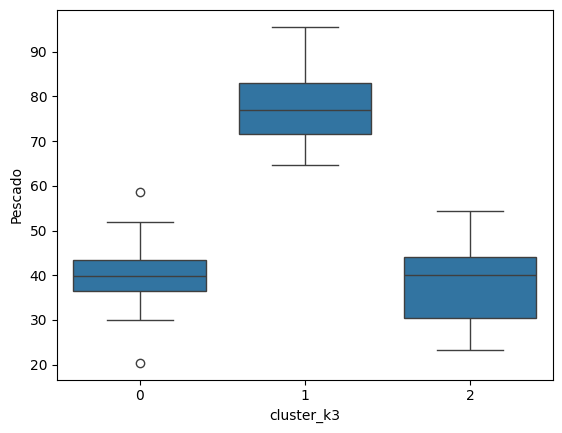

In [106]:
sns.boxplot(data_mercado, x='cluster_k3', y='Pescado')

<Axes: xlabel='cluster_k3', ylabel='Embutidos'>

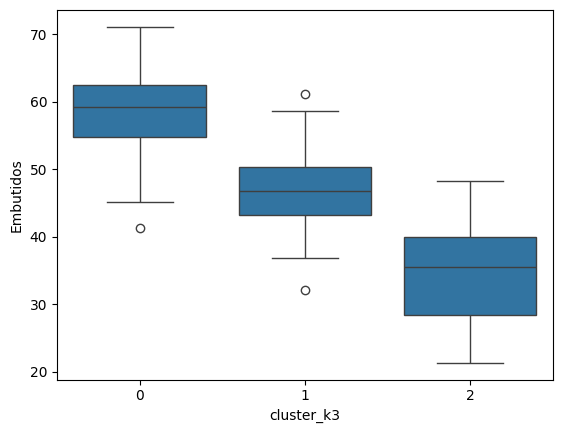

In [107]:
sns.boxplot(data_mercado, x='cluster_k3', y='Embutidos')

<Axes: xlabel='cluster_k3', ylabel='Carne'>

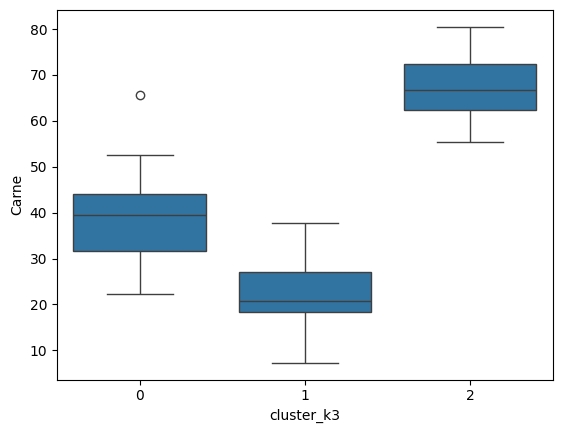

In [108]:
sns.boxplot(data_mercado, x='cluster_k3', y='Carne')

<Axes: xlabel='cluster_k3', ylabel='Pollo'>

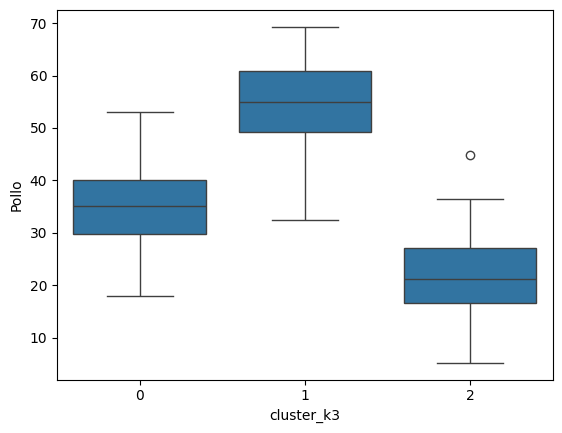

In [109]:
sns.boxplot(data_mercado, x='cluster_k3', y='Pollo')

__Consolidando Segmentaciones__

<Axes: xlabel='cluster_k3', ylabel='value'>

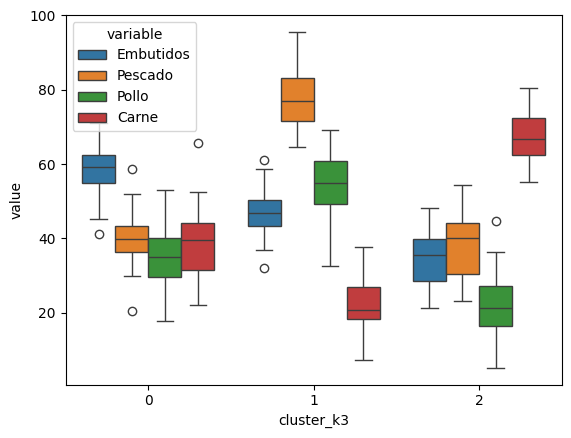

In [110]:
data_vert = pd.melt(data_mercado, id_vars=['cluster_k3'])
sns.boxplot(data_vert, x='cluster_k3', y='value', hue='variable')